# Проект: Аналитика продаж маркетплейса

Вы — аналитик данных, и сейчас идёте в стартап, который создает новый маркетплейс. Он недавно появился на рынке и занимается продажей новых товаров из Бразилии, которые только начинают поступать в продажу.

Продакт-менеджер Петя переживает за свой продукт, так как выручка маркетплейса стоит на месте уже несколько месяцев. Он предложил вам полную свободу действий. Главное — чтобы метрики росли, а мы не причиняли неудобства клиентам, ведь Петя заботится об их опыте.

**Задачи**
 - Задача 1: Оценить месячный retention в оформление заказа с помощью когортного анализа.
 - Задача 2: Определить, существует ли product/market fit у этого маркетплейса.
 - Задача 3: Определить 5 основных метрик, на которых продакту можно сконцентрироваться, чтобы максимизировать прибыль компании.
 - Задача 4: Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.
 - Задача 5: Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.
 - Задача 6: Сформулировать выводы о проделанной работе и составить отчет.

### Подготовка данных для анализа

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

from operator import attrgetter

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors

Загрузка данных и простой анализ

1. Таблица - olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей

 - customer_id — позаказный идентификатор пользователя
 - customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)
 - customer_zip_code_prefix — почтовый индекс пользователя
 - customer_city — город доставки пользователя
 - customer_state — штат доставки пользователя

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

2. Таблица - olist_orders_dataset.csv —  таблица заказов

 - order_id — уникальный идентификатор заказа (номер чека)
 - customer_id — позаказный идентификатор пользователя
 - order_status — статус заказа
 - order_purchase_timestamp — время создания заказа
 - order_approved_at — время подтверждения оплаты заказа 
 - order_delivered_carrier_date — время передачи заказа в логистическую службу
 - order_delivered_customer_date — время доставки заказа
 - order_estimated_delivery_date — обещанная дата доставки

Уникальные статусы заказов в таблице olist_orders_dataset:

 -  created — создан;
 -  approved — подтверждён;
 -  invoiced — выставлен счёт;
 -  processing — в процессе сборки заказа;
 -  shipped — отгружён со склада;
 -  delivered — доставлен пользователю;
 -  unavailable — заказ отменён по причине недоступности товара;;
 -  canceled — отменён.

In [6]:
orders = pd.read_csv('olist_orders_dataset.csv')

In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [9]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Преобразование типа данных временных колонок в datetime

In [10]:
orders[['order_purchase_timestamp', \
        'order_approved_at', \
        'order_delivered_carrier_date', \
        'order_delivered_customer_date', \
        'order_estimated_delivery_date']] = orders[['order_purchase_timestamp', \
                                                    'order_approved_at', \
                                                    'order_delivered_carrier_date', \
                                                    'order_delivered_customer_date', \
                                                    'order_estimated_delivery_date']]\
                                                    .apply(pd.to_datetime, errors='coerce')

In [11]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

3. Таблица - olist_order_items_dataset.csv — товарные позиции, входящие в заказы

 -  order_id — уникальный идентификатор заказа (номер чека)
 -  order_item_id — идентификатор товара внутри одного заказа
 -  product_id — ид товара (аналог штрихкода)
 -  seller_id — ид производителя товара
 -  shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике
 -  price — цена за единицу товара
 -  freight_value — стоимость доставки

In [12]:
orders_items = pd.read_csv('olist_order_items_dataset.csv')

In [13]:
orders_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
orders_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [15]:
orders_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Преобразование типа данных временных колонок в datetime

In [16]:
orders_items.shipping_limit_date = pd.to_datetime(orders_items.shipping_limit_date)

In [17]:
orders_items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

### Задача 1. Оценка Retention

Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

 - Исследовать датасет и определить, какой вид заказа будет учитываться в retention
 - Построить месячный retention
 - Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
 - Найти когорту с самым высоким retention на 3-й месяц.
 - Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

**1. Исследовать датасет и определить, какой вид заказа будет учитываться в retention**

In [19]:
orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13


Посмотрим на распределение заказов по статусам

In [20]:
order_status_dist = orders.groupby('order_status', as_index=False).agg({'order_id':'count'})\
                            .sort_values(by='order_id', ascending=False)
order_status_dist['percentage'] = (order_status_dist['order_id'] / order_status_dist['order_id'].sum() * 100).round(2)

In [21]:
order_status_dist

,order_status,order_id,percentage
3,delivered,96478,97.02
6,shipped,1107,1.11
1,canceled,625,0.63
7,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
2,created,5,0.01
0,approved,2,0.00


В расчете retention будем учитывать следующий вид заказа:

 - 1 - колонку "order_purchase_timestamp", содержащую время создания заказа, так как именно создание заказа показывает целевое действие покупателя как инициативу с его стороны вернуться на маркетплейс

 - 2 - статусы заказов:

  - а - учитываем:
created — создан
approved — подтверждён
invoiced — выставлен счёт
processing — в процессе сборки заказа
shipped — отгружён со склада
delivered — доставлен пользователю

  - б - не учитываем:
unavailable — заказ отменён по причине недоступности товара
canceled — отменён

Было принято решение не ограничиваться только статусом заказов "delivered", а также считать успешными статусы создания, подтверждения, выставления счета, сборки и отгрузки заказа. Все кроме отмененных заказов. 

Мы работаем в компании-стартапе и нам важно учитывать не только полностью завершенные заказы, но и заказы, в которых пользователь проявил намерение совершить покупку - выбрал товар, принял решение и проявил инициативу.
А то, что логистическая стужба еще не успела доставить посылку - это уже внутренние процессы, которые не отменяют факт возвращения пользователя в продукт и совершение целевого действия.

**2. Построить месячный retention**

Объединяем 2 таблицы, чтобы получить доступ к уникальному id покупателя

In [24]:
customers_orders_merge = orders.merge(customers, on='customer_id')

In [25]:
customers_orders_merge.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA


Создаем список успешных статусов и фильтруем датасет по успешным заказам

In [26]:
retention_status_list = ['created', 'approved', 'invoiced', 'processing', 'shipped', 'delivered']

In [27]:
merge_statuses = customers_orders_merge.query('order_status in @retention_status_list')

In [28]:
df_retention = merge_statuses[['customer_unique_id', 'order_purchase_timestamp']].copy()
df_retention.head()

,customer_unique_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


Извлекаем месяц и день заказа

In [29]:
df_retention['order_period_day'] = df_retention['order_purchase_timestamp'].dt.to_period('D')
df_retention['order_period'] = df_retention['order_purchase_timestamp'].dt.to_period('M')

Присваиваем когорты на основе даты первого действия для каждого пользователя

In [30]:
df_retention['cohort_day'] = df_retention.groupby('customer_unique_id')['order_purchase_timestamp']\
                                .transform('min').dt.to_period('D')
df_retention['cohort'] = df_retention.groupby('customer_unique_id')['order_purchase_timestamp']\
                                .transform('min').dt.to_period('M')

Рассчитываем номер периода в днях 

In [31]:
df_retention['period_number_month'] = (df_retention.order_period - df_retention.cohort).apply(attrgetter('n'))

In [32]:
df_retention.head()

,customer_unique_id,order_purchase_timestamp,order_period_day,order_period,cohort_day,cohort,period_number_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-02,2017-10,2017-09-04,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07-24,2018-07,2018-07-24,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-08,2018-08,2018-08-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11-18,2017-11,2017-11-18,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-13,2018-02,2018-02-13,2018-02,0


Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)

In [33]:
df_cohort = df_retention.groupby(['cohort', 'period_number_month'])\
                        .agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [34]:
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0,2
1,2016-10,0,290
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


Создаем сводную таблицу для когортного анализа

In [35]:
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')
cohort_pivot

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,290.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,752.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1690.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2571.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2325.0,14.0,5.0,4.0,7.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3541.0,17.0,17.0,14.0,11.0,12.0,15.0,5.0,9.0,9.0,9.0,12.0,9.0,1.0,7.0,8.0,NaN,NaN,NaN,NaN
2017-06,3102.0,14.0,11.0,12.0,8.0,12.0,11.0,7.0,4.0,7.0,10.0,10.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


Рассчитываем размеры когорт (первый столбец сводной таблицы)

In [36]:
cohort_size = cohort_pivot.iloc[:, 0]

Вычисляем коэффициенты удержания, деля на размер когорты

In [37]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003448,NaN,NaN,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,0.006897,0.006897
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003989,0.002660,0.001330,0.003989,0.001330,0.003989,0.001330,0.001330,NaN,0.003989,0.001330,0.006649,0.003989,0.001330,0.001330,0.002660,0.003989,0.001330,NaN
2017-02,1.0,0.002367,0.002959,0.001183,0.004142,0.001183,0.002367,0.001775,0.001183,0.001775,0.001183,0.002959,0.001183,0.001775,0.001183,0.000592,0.000592,0.002367,NaN,NaN
2017-03,1.0,0.005056,0.003501,0.003890,0.003501,0.001556,0.001556,0.003112,0.003501,0.000778,0.003890,0.001167,0.002334,0.001167,0.001556,0.002334,0.000778,0.001556,NaN,NaN
2017-04,1.0,0.006022,0.002151,0.001720,0.003011,0.002581,0.003441,0.003011,0.003011,0.001720,0.002581,0.000860,0.000860,0.000430,0.000860,0.000860,0.001290,NaN,NaN,NaN
2017-05,1.0,0.004801,0.004801,0.003954,0.003106,0.003389,0.004236,0.001412,0.002542,0.002542,0.002542,0.003389,0.002542,0.000282,0.001977,0.002259,NaN,NaN,NaN,NaN
2017-06,1.0,0.004513,0.003546,0.003868,0.002579,0.003868,0.003546,0.002257,0.001289,0.002257,0.003224,0.003224,0.001612,0.001289,0.001934,NaN,NaN,NaN,NaN,NaN


**3. Проанализировать, чему равен медианный retention 1-го месяца**

In [39]:
retention_first_month = retention_matrix[1].median()

print(f'Медианный retention 1го месяца: {retention_first_month:.4f}')

Медианный retention 1го месяца: 0.0051


**4. Найти когорту с самым высоким retention на 3-й месяц**

In [41]:
cohort_3month_max = retention_matrix[3].idxmax()

print(f'Когорта с самым высоким retention на 3-й месяц: {cohort_3month_max}')

Когорта с самым высоким retention на 3-й месяц: 2017-05


**5. Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия**

In [43]:
# для тепловой карты убираем первый столбец нулевого месяца
retention_matrix_heatmap = retention_matrix.iloc[:, 1:].copy()
retention_matrix_heatmap.head()

period_number_month,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,
2016-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,NaN,NaN,NaN,NaN,NaN,0.003448,NaN,NaN,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,0.006897,0.006897
2016-12,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,0.003989,0.002660,0.001330,0.003989,0.001330,0.003989,0.001330,0.001330,NaN,0.003989,0.001330,0.006649,0.003989,0.001330,0.001330,0.002660,0.003989,0.001330,NaN
2017-02,0.002367,0.002959,0.001183,0.004142,0.001183,0.002367,0.001775,0.001183,0.001775,0.001183,0.002959,0.001183,0.001775,0.001183,0.000592,0.000592,0.002367,NaN,NaN


Тепловая карта когортного анализа (Heatmap)

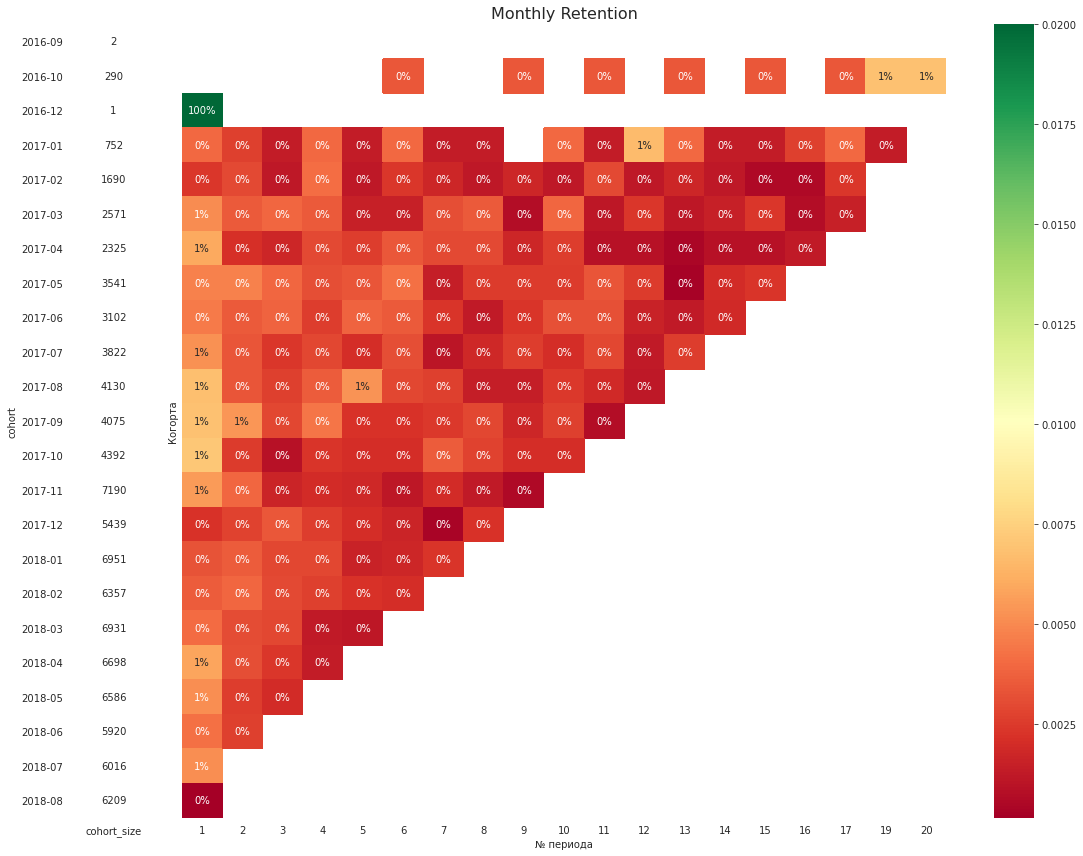

In [44]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix_heatmap,
                mask=retention_matrix_heatmap.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1],
                vmax=0.02)
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

### Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно:

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

- Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
- Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
- Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

**1. Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге**

In [47]:
# добавляем последней строкой медиану retention по каждому месяцу, используем датасет сразу без нулевого месяца 
retention_matrix_heatmap.loc['Median'] = retention_matrix_heatmap.median(axis=0)

In [48]:
retention_matrix_heatmap.tail()

period_number_month,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,
2018-05,0.005162,0.002581,0.001974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06,0.004223,0.002703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-07,0.005153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08,0.000161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Median,0.005056,0.003263,0.002663,0.002878,0.002049,0.002367,0.002257,0.002019,0.001775,0.002561,0.002408,0.00146,0.001532,0.001443,0.001795,0.001034,0.002908,0.004113,0.006897


In [49]:
# Извлекаем строку с медианой (в виде Series) и преобразуем в проценты
median_retention = retention_matrix_heatmap.loc['Median']*100
median_retention

period_number_month
1     0.505640
2     0.326255
3     0.266344
4     0.287768
5     0.204918
6     0.236686
7     0.225661
8     0.201889
9     0.177515
10    0.256115
11    0.240756
12    0.146004
13    0.153232
14    0.144280
15    0.179452
16    0.103412
17    0.290757
19    0.411317
20    0.689655
Name: Median, dtype: float64

In [50]:
# Смотрим на описательные характеристики распределения медиан retention
median_retention.describe()

count    19.000000
mean      0.265666
std       0.140928
min       0.103412
25%       0.178483
50%       0.236686
75%       0.289262
max       0.689655
Name: Median, dtype: float64

График медианного retention

Text(0.5, 1.0, 'Кривая медианного Retention')

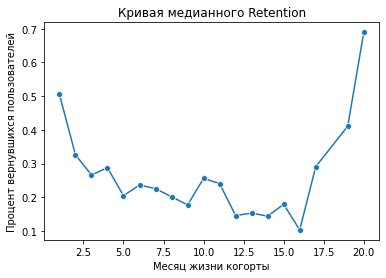

In [51]:
sns.lineplot(x=median_retention.index, y=median_retention.values, marker='o')
plt.xlabel("Месяц жизни когорты")
plt.ylabel("Процент вернувшихся пользователей")
plt.title("Кривая медианного Retention")

**2. Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время**
 - Если PMF есть, то в какую сторону лучше развивать продукт дальше?
 - Если PMF нет, то какие причины могут быть у этого?

**Комментарии к графику Retention**

Все значения находятся на крайне низком уровне от почти 0% до 0,7%

В первые месяцы график неуклонно снижается почти до 0, а в последние месяцы резко поднимается вверх, что связанно с эффектом малой выборки. То есть для первого месяца есть данные по всем когортам, а на последних месяцах - по одной или двум самым старым когортам.
Из-за этого медиана рассчитывается по очень малому числу наблюдений. Если в одной из этих старых когорт пара человек случайно совершила покупку, процент удержания на графике резко подскакивает. Этот всплеск является математическим шумом, а не реальным трендом retention.

Чтобы оценить PMF по такому графику, лучше смотреть только первые месяцы - с 1го по 5й или 6й, где данных еще достаточно почти по всем когортам. Эта часть кривой во-первых неуклонно снижается, а во-вторых находится на крайне низких значениях от 0.2% до 0.5%.

Отсюда можно сделать вывод об отсутствии Product/Market fit - пользователи совершают разовую покупку и больше не возвращаются (эффект «дырявого ведра»).

**Возможные причины такой ситуации**
- товары долго доставляются до покупателей из Бразилии и они не хотят ждать новых покупок
- товары нерегулярного спроса
- товары не соответствуют потребностям этой аудитории
- товары низкого качества

Чтобы исправить ситуацию, нужно работать над тем, чтобы покупатель возвращался за второй и последующими покупками:
 - Удержание пользователей (Retention Rate)
 - Доля повторных покупок (Repeat Purchase Rate / конверсия в повторную покупку)
 - Прибыль, получаемую за всю жизнь пользователя (LTV - lifetime value)

Возможные варианты:
 - сократить срок доставки
 - сделать ассортимент - регулярным, качественным, соответсвующим потребностям этой аудитории

**3. Подкрепить свои выводы релевантной визуализацией, удобной для восприятия**

См выше графики:
1. График медианного retention
2. Тепловая карта когортного анализа

### Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

 - Первая метрика должна отражать рост объёма продаж маркетплейса.
 - Вторая — показывать объем аудитории, которой продукт доставляет ценность.
 - Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
 - Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
 - Пятая — отражать денежное выражение вовлеченности клиента.

Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

**1. Первая метрика должна отражать рост объёма продаж маркетплейса**

**Первая метрика - GMV (Gross Merchandise Value - валовый объем оборота товаров)**

In [60]:
# объединяем 2 таблицы, чтобы получить доступ к статусам, времени создания заказа (группировка по месяца), ценам
orders_oi_merge = orders.merge(orders_items, on='order_id')

In [61]:
# список успешных заказов по нашей методологии (все кроме отмененных)
status_list = ['created', 'approved', 'invoiced', 'processing', 'shipped', 'delivered']

In [62]:
# фильтруем только по успешным заказам
o_oi_merge_statuses = orders_oi_merge.query('order_status in @status_list').copy()

In [63]:
# добавляем колонку месяца заказа
o_oi_merge_statuses['order_period'] = o_oi_merge_statuses['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

In [64]:
# расчитываем метрику GMV по месяцам
df_gmv = o_oi_merge_statuses.groupby('order_period', as_index=False)\
                            .agg({'price':'sum'})\
                            .rename(columns={'price':'GMV'})

In [65]:
df_gmv.head()

,order_period,GMV
0,2016-09-01,207.86
1,2016-10-01,44507.30
2,2016-12-01,10.90
3,2017-01-01,120098.27
4,2017-02-01,244959.35


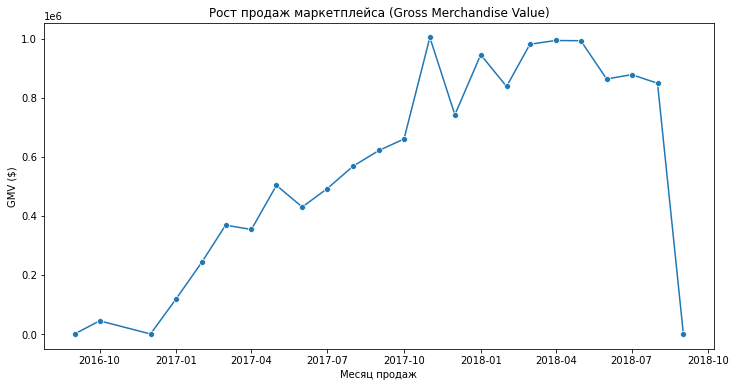

In [66]:
# График GMV

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_gmv, x='order_period', y='GMV', marker='o')

plt.xlabel("Месяц продаж")
plt.ylabel("GMV ($)")
plt.title("Рост продаж маркетплейса (Gross Merchandise Value)")

plt.show()

**2. Вторая — показывать объем аудитории, которой продукт доставляет ценность**

**Вторая метрика - Количество активных платящих клиентов - Monthly Active Buyers (число уникальных платящих пользователей). Если покупатель совершил покупку (хотя бы одну за месяц), то он нашел ценность а нашем продукте.**

In [69]:
# воспользуемся уже готовыми данными, где есть уникальный пользователь и месяц покупки (создания заказа),
# а также только успешные заказы (убраны все отмененные)
df_retention.head()

,customer_unique_id,order_purchase_timestamp,order_period_day,order_period,cohort_day,cohort,period_number_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-02,2017-10,2017-09-04,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07-24,2018-07,2018-07-24,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-08,2018-08,2018-08-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11-18,2017-11,2017-11-18,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-13,2018-02,2018-02-13,2018-02,0


In [70]:
df_mab_full = df_retention.copy()

In [71]:
df_mab_full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98207 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        98207 non-null  object        
 1   order_purchase_timestamp  98207 non-null  datetime64[ns]
 2   order_period_day          98207 non-null  period[D]     
 3   order_period              98207 non-null  period[M]     
 4   cohort_day                98207 non-null  period[D]     
 5   cohort                    98207 non-null  period[M]     
 6   period_number_month       98207 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1), period[D](2), period[M](2)
memory usage: 6.0+ MB


In [72]:
df_mab_full['order_period'] = df_mab_full['order_period'].dt.to_timestamp()

In [73]:
# создадим датафрейм - количество уникальныз покупателей по месяцам покупки
df_mab = df_mab_full.groupby(['order_period'])\
                        .agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [74]:
df_mab.head()

,order_period,n_customers
0,2016-09-01,2
1,2016-10-01,290
2,2016-12-01,1
3,2017-01-01,753
4,2017-02-01,1693


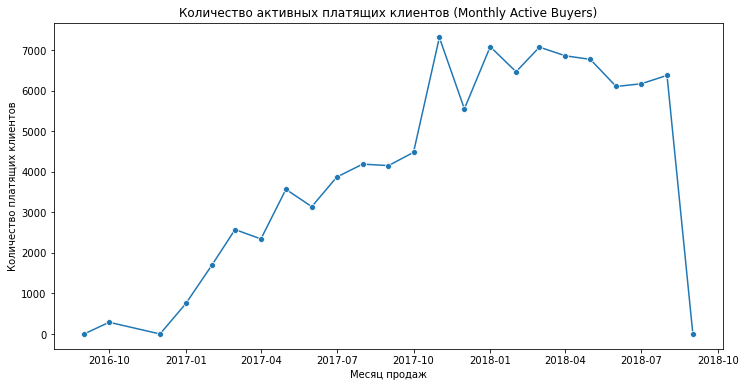

In [75]:
# График Monthly Active Buyers

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_mab, x='order_period', y='n_customers', marker='o')

plt.xlabel("Месяц продаж")
plt.ylabel("Количество платящих клиентов")
plt.title("Количество активных платящих клиентов (Monthly Active Buyers)")

plt.show()

**3. Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных)**

**Третья метрика - конверсия из первого посещения сайта в первую покупку. Если пользователь посетил наш сайт и совершил первую покупку - это показывает заинтересованность новых клиентов в нашем продукте и эффективность конвертации маркетплейса в покупателя.** 

**4. Четвёртая — отражать вовлеченность клиента в продолжение использования продукта**

**Четверая метрика - Конверсия в повторный заказ через расчет Retention Rate. Показывает долю клиентов, которые продолжают использовать продукт после 1го месяца, значит маркетплейс удовлетворяет их потребности.**

In [80]:
# Расчитаем Retention Rate по срезу 1-го месяца

In [81]:
retention_matrix.head()

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003448,NaN,NaN,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,0.006897,0.006897
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003989,0.002660,0.001330,0.003989,0.001330,0.003989,0.001330,0.001330,NaN,0.003989,0.001330,0.006649,0.003989,0.001330,0.001330,0.002660,0.003989,0.001330,NaN
2017-02,1.0,0.002367,0.002959,0.001183,0.004142,0.001183,0.002367,0.001775,0.001183,0.001775,0.001183,0.002959,0.001183,0.001775,0.001183,0.000592,0.000592,0.002367,NaN,NaN


In [82]:
# берем 1й месяц
ret_1month = retention_matrix[1]

In [83]:
# Оставляем всё, кроме последнего элемента (медианы)
ret_1month = ret_1month[:-1]

In [84]:
# подготовим датафрейм для графика
df_ret_1month = ret_1month.reset_index()

In [85]:
df_ret_1month.columns = ['cohort', 'retention']

In [86]:
df_ret_1month['cohort'] = pd.to_datetime(df_ret_1month['cohort'].astype(str))

In [87]:
df_ret_1month

,cohort,retention
0,2016-09-01,NaN
1,2016-10-01,NaN
2,2016-12-01,1.000000
3,2017-01-01,0.003989
4,2017-02-01,0.002367
5,2017-03-01,0.005056
6,2017-04-01,0.006022
7,2017-05-01,0.004801
8,2017-06-01,0.004513
9,2017-07-01,0.005233


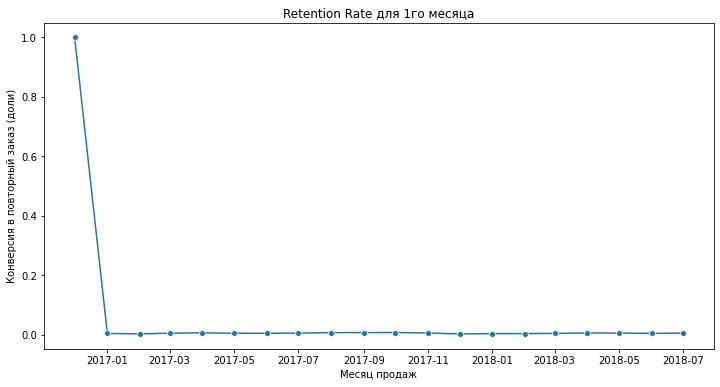

In [88]:
# График Retention Rate для первого месяца

plt.figure(figsize=(12, 6))

sns.lineplot(x=df_ret_1month.cohort, y=df_ret_1month.retention, marker='o')

plt.xlabel("Месяц продаж")
plt.ylabel("Конверсия в повторный заказ (доли)")
plt.title("Retention Rate для 1го месяца")

plt.ticklabel_format(style='plain', axis='y')
plt.show()

**5. Пятая — отражать денежное выражение вовлеченности клиента**

**Пятая метрика - ARPPU (Average Revenue Per Paying User) - показывает среднюю выручку с одного клиента. Считается как ARPPU = Revenue / PayingUsers**

In [91]:
o_oi_merge_statuses.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_period
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07-01


In [92]:
# объединим все три датасета, уже отфильтрованные по успешным заказам (ранее исключили отмененные статусы)
all_data_merge = o_oi_merge_statuses.merge(customers, on='customer_id')

In [93]:
# создадим датафрейм только с тремя необходимыми полями
data_merge = all_data_merge[['order_period', 'price', 'customer_unique_id']]

In [94]:
data_merge.head()

,order_period,price,customer_unique_id
0,2017-10-01,29.99,7c396fd4830fd04220f754e42b4e5bff
1,2018-07-01,118.70,af07308b275d755c9edb36a90c618231
2,2018-08-01,159.90,3a653a41f6f9fc3d2a113cf8398680e8
3,2017-11-01,45.00,7c142cf63193a1473d2e66489a9ae977
4,2018-02-01,19.90,72632f0f9dd73dfee390c9b22eb56dd6


In [95]:
# сгруппируем по месяцам, расчитаем GMV и кол-во уникальных платящих пользователей
df_ARPPU = data_merge.groupby('order_period', as_index=False)\
                            .agg({'price':'sum', 'customer_unique_id':'nunique'})\
                            .rename(columns={'price':'GMV', 'customer_unique_id':'n_customers'})

In [96]:
# расчет метрики
df_ARPPU['ARPPU'] = df_ARPPU['GMV']/df_ARPPU['n_customers']

In [97]:
df_ARPPU.head()

,order_period,GMV,n_customers,ARPPU
0,2016-09-01,207.86,2,103.930000
1,2016-10-01,44507.30,287,155.077700
2,2016-12-01,10.90,1,10.900000
3,2017-01-01,120098.27,753,159.493054
4,2017-02-01,244959.35,1693,144.689516


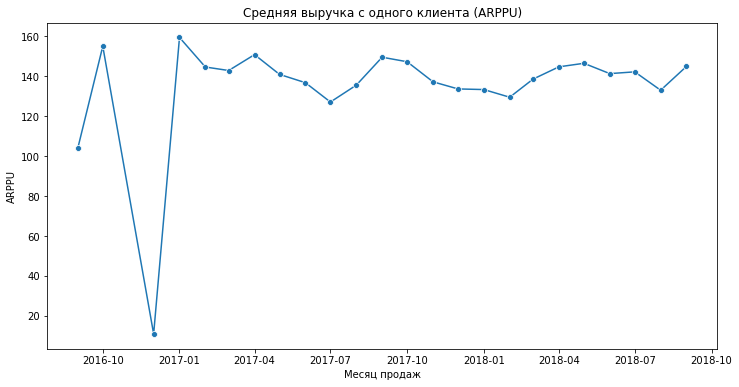

In [98]:
# График ARPPU

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_ARPPU, x='order_period', y='ARPPU', marker='o')

plt.xlabel("Месяц продаж")
plt.ylabel("ARPPU")
plt.title("Средняя выручка с одного клиента (ARPPU)")

plt.show()

### Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

Для перевода метрики в Impact воспользуйтесь шкалой.

**1. Расчет Impact для гипотезы 1 (Исправление бага в системе процессинга)**

Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

In [101]:
# создадим копию данных по заказам
df_orders = orders.copy()

In [102]:
df_orders['order_period'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

In [103]:
# отфильтруем заказы с июня 2017 года
df_orders = df_orders.query('order_period >= "2017-06"')

In [104]:
# по каждому статусу посмотрим кол-во заказов
status_dist = df_orders.groupby('order_status', as_index=False).agg({'order_id':'count'})\
                            .sort_values(by='order_id', ascending=False)\
                            .rename(columns={'order_id':'n_orders'})

In [105]:
status_dist

,order_status,n_orders
2,delivered,85413
5,shipped,912
0,canceled,499
6,unavailable,475
3,invoiced,240
4,processing,202
1,created,5


In [106]:
# отфильтруем только отмененные заказы
cancelled_orders = status_dist.query('order_status in ["unavailable", "canceled"]')
cancelled_orders

,order_status,n_orders
0,canceled,499
6,unavailable,475


In [107]:
total_cancelled = cancelled_orders['n_orders'].sum()
print(f'Количество отмененных заказов и эффект от 1й гипотезы: {total_cancelled}')

Количество отмененных заказов и эффект от 1й гипотезы: 974


 - Количество отменнных заказов = 974, эта та величина, на которую может повысится кол-во заказов при применении 1й гипотезы.
 - Impact по таблице = 5

**2. Расчет Impact для гипотезы 2 (Сокращение времени до отгрузки)**

Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

Эффект от гипотезы = Количество задержанных заказов × Retention (возьмем - медианный retention 1-го месяца в долях)

In [111]:
# Будем считать, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта)
print(f'Медианный retention 1го месяца: {retention_first_month:.4f}')

Медианный retention 1го месяца: 0.0051


In [112]:
# Берем этот датасет, в котором отфильтрованные для 1й гипотезы заказы - созданные с июня 2017 года
df_orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_period
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07


In [113]:
# отфильтруем задержанные заказы - дата доставки позже ожидаемой
orders_delayed = df_orders.query('order_delivered_customer_date > order_estimated_delivery_date')

In [114]:
orders_delayed_sum = orders_delayed.order_id.count()
print(f'Количество задержанных заказов: {orders_delayed_sum}')

Количество задержанных заказов: 7296


In [115]:
impact_2 = orders_delayed_sum * retention_first_month
print(f'Эффект от 2й гипотезы: {impact_2:.2f}')

Эффект от 2й гипотезы: 36.89


 - Эффект = 36.89, эта та величина, на которую может повысится число повторных заказов при применении 2й гипотезы
 - Impact по таблице = 1

**3. Расчет Impact для гипотезы 3 (Новый способ оплаты)**

Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

Эффект от гипотезы = Количество пользователей с 1 заказом × Retention (возьмем - медианный retention 1-го месяца в долях)

In [119]:
# Берем этот датасет, в котором отфильтрованные для 1й гипотезы заказы - созданные с июня 2017 года
df_orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_period
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07


In [120]:
cust_orders_merge = df_orders.merge(customers, on='customer_id')

In [121]:
cust_orders_merge.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_period,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA


In [122]:
# создадим датафрейм, где по каждому уникальному пользователю отражается кол-во заказов
cust_n_orders = cust_orders_merge.groupby('customer_unique_id', as_index=False)\
                    .agg({'order_id':'count'})\
                    .rename(columns={'order_id':'n_orders'})\
                    .sort_values(by='n_orders')
cust_n_orders

,customer_unique_id,n_orders
56270,a9088d439d83c94aef38ee4846e31559,1
56280,a90f28cacd952c0e995ac0f08e35f03c,1
56279,a90e373bc4cbe53829d41a1adbbbab94,1
56278,a90d5eb21d1ee630c63f984b78210dc7,1
56277,a90cf5a43a177612976f70bdccffbd0e,1
...,...,...
9128,1b6c7548a2a1f9037c1fd3ddfed95f33,7
33458,6469f99c1f9dfae7733b25662e7f1782,7
67329,ca77025e7201e3b30c44b472ff346268,7
20756,3e43e6105506432c953e165fb2acf44c,9


In [123]:
# возмем пользователей только с одним заказом
cust_one_order = cust_n_orders.query('n_orders == 1')
cust_one_order

,customer_unique_id,n_orders
56270,a9088d439d83c94aef38ee4846e31559,1
56280,a90f28cacd952c0e995ac0f08e35f03c,1
56279,a90e373bc4cbe53829d41a1adbbbab94,1
56278,a90d5eb21d1ee630c63f984b78210dc7,1
56277,a90cf5a43a177612976f70bdccffbd0e,1
...,...,...
28061,544d24409f1ea525dfd74b6d0bc7d633,1
28510,559a8ee3945ef2efb08cf74e36c8b747,1
28497,5595496b890da66fb3e1b56420dddeca,1
28098,54653f06e7ac2838ec6762132575c281,1


In [124]:
# эффект от 3й гипотезы = произведение кол-во уникальных пользователей с одним заказом на медианный retention 1-го месяца
impact_3 = cust_one_order.n_orders.sum() * retention_first_month
print(f'Эффект от 3й гипотезы: {impact_3:.2f}')

Эффект от 3й гипотезы: 417.45


 - Эффект = 417.45, эта та величина, на которую может повысится число повторных заказов при применении 3й гипотезы
 - Impact по таблице = 4

**4. Расчет ICE для 3х гипотез**

In [127]:
ICE_1 = 5*8*6
print(f'ICE 1й гипотезы: {ICE_1}')

ICE 1й гипотезы: 240


In [128]:
ICE_2 = 1*10*4
print(f'ICE 2й гипотезы: {ICE_2}')

ICE 2й гипотезы: 40


In [129]:
ICE_3 = 4*5*9
print(f'ICE 3й гипотезы: {ICE_3}')

ICE 3й гипотезы: 180


Гипотеза 1 (Исправление бага в системе процессинга) имеет самый высокий ICE, значит, выбираем ее.

### Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

 - Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
 - Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

Мы выбрали гипотезу 1 - Исправление бага в системе процессинга:
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

**1 - Целевая метрика - GMV (Gross Merchandise Value - валовый объем оборота товаров)**

Эта метрика позволяет оценить реальный бизнес-эффект и финансовый рост от эффекта гипотезы. 

Она напрямую отвечает на главный запрос продакт-менеджера (рост выручки маркетплейса) и идеально соотносится с гипотезой.

Если мы предотвратим отмены из-за бага, то большее количество товаров будет успешно доставлено и оплачено, что мгновенно отразится на валовом объеме оборота.

**2 - Прокси метрика - Конверсия из создания заказа в доставку (статус delivered)**

Эта метрика поможет быстро зафиксировать технический успех эксперимента на промежуточном этапе. 

Она очень чутко и быстро среагирует на исправление бага в процессинге.

Если система перестанет отменять заказы на полпути, доля успешно дошедших до финала покупок сразу же вырастет.

**3 - Guardrail метрика - Количество обращений в поддержку**

Эта метрика подстрахует от непредвиденных сбоев при внедрении изменений.

В целом, эта метрика хорошо подходит для любых технических изменений в процессинге.

Если в процессе исправления бага мы случайно усложним интерфейс или сломаем альтернативные сценарии оплаты, мы сразу увидим всплеск обращений, что позволит вовремя остановить эксперимент.

### Задача 6. Выводы о проделанной работе. Отчет для продакт-менеджера.

**1. Проблема**

Для того, чтобы разобраться, почему выручка маркетплейса стоит на месте уже несколько месяцев, был проведен анализ:

 -  Только 0,5% покупателей совершают повторную покупку в следующий месяц после первой покупки
 -  По сути, покупатели совершают разовую покупку и больше не возвращаются
 -  Это эффект «дырявого ведра» - сколько бы новых покупателей ни приходило на маркетплейс, они будут утекать и не возвращаться
 -  Поэтому выручка стоит на месте

**2. Анализ и выводы**

Что было сделано:

**А. Выводы по возвращаемости**

Мы смотрели на процент вернувшихся пользователей за повторной покупкой:
 -  с сентября 2016 по август 2018 - в среднем только 0,24% пользователей вернулись
 -  в первый месяц после покупки – 0,51%

То есть пользователи совершают разовую покупку и не возвращаются.
Визуально это отражает Тепловая карта когортного анализа (Heatmap) - см выше.

**Б. Выбор метрик**

Мы определили и рассчитали 5 основных метрик, на которых можно сконцентрироваться, чтобы максимизировать прибыль компании:

 - 1. Gross Merchandise Value (GMV) отражает рост объёма продаж маркетплейса
 - 2. Количество активных платящих клиентов (Monthly Active Buyers) показывает аудиторию, получающую ценность
 - 3. Конверсия из первого посещения сайта в первую покупку отражает интерес новых клиентов в продукте
 - 4. Конверсия в повторный заказ показывает вовлеченность клиента в продолжение использования продукта
 - 5. Average Revenue Per Paying User (ARPPU) выступает в роли денежного выражения этой вовлеченности

**В. Выбор гипотезы**

Мы выбрали самую потенциально перспективную гипотезу для улучшения ситуации.

Гипотеза - исправление бага в системе процессинга, чтобы избавиться от всех отмененных заказов и увеличить количество доставленных заказов.


**Г. Метрики для эксперимента**

Метрики для определения эффективности гипотезы:
 -  Целевая метрика - GMV
 -  Прокси метрика - Конверсия из создания заказа в доставку 
 -  Guardrail метрика - Количество обращений в поддержку

**3. Рекомендации**

Сейчас точно не стоит фокусироваться на масштабировании – новые клиенты будут утекать.

Нужно сфокусироваться на доработке продукта:

1. Исправить баг в системе процессинга.
Сейчас доставленные заказы составляют 97,3% от всех, если отмененные заказы станут доставленными, то конверсия увеличится еще на 1,1% и, как следствие, это положительно повлияет на пользовательский опыт и повысит долю повторных заказов.

2. Поисследовать процесс доставки.
Возможно, существенное сокращение срока доставки товаров из Бразилии повлияет на пользовательский опыт и повысит возвращаемость клиентов.

3. Поисследовать ассортимент товаров.
Возможно, товары на маркетплейсе низкого качества, нерегулярного спроса или не соответствуют потребностям нашей аудитории.
